# Task 3.2 — Failure Mode Analysis

**Paper:** *A Dual Coordinate Descent Method for Large-scale Linear SVM*  
**Student:** Navnit Naman | Roll: 230085

## Failure Scenario Description

**Scenario:** DCD-based Linear SVM on a **non-linearly separable dataset with concentric circles** (XOR-like structure), specifically a 2D dataset where one class occupies the inner ring and the other occupies the outer ring. In this case, no linear decision boundary (hyperplane in the original feature space) can correctly classify the two classes with low hinge loss.

**Why we expect DCD to struggle here:** DCD's design assumes that the data is linearly separable or at least approximately so in the **original feature space** — this is the defining characteristic of Linear SVM as opposed to Kernel SVM. The paper's method works directly on the dual form using inner products xᵢᵀxⱼ (Qᵢⱼ = yᵢyⱼxᵢᵀxⱼ, Eq. 4) without applying any nonlinear mapping φ(x). This is precisely Assumption 1 from Task 1.2: the method depends on the data being amenable to linear separation. The concentric circles dataset violates this assumption fundamentally — no choice of C or number of DCD iterations can overcome the geometric impossibility of separating the inner ring from the outer ring with a hyperplane. The algorithm will converge (it always does, by Theorem 1) but to a poor classifier, because the best linear boundary is barely better than random.

**Connection to Task 1.2 assumptions:** This failure mode directly exploits Assumption 1 (linear kernel / linear separability in original feature space) from Task 1.2. The paper states that linear SVM is appropriate when 'the performances are similar with/without nonlinear mapping' (Introduction, Section 1). Our failure dataset is one where a nonlinear mapping is *essential*, and the linear model fails fundamentally.

In [1]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC  # RBF SVM for comparison

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

C = 1.0
EPSILON = 1e-4
MAX_ITER = 100

print("Setup complete.")

Setup complete.


In [2]:
# ============================================================
# Failure Dataset: make_circles (non-linearly separable)
# ============================================================
X_circ, y_circ = make_circles(n_samples=800, noise=0.1, factor=0.4, random_state=RANDOM_SEED)
y_circ = 2 * y_circ - 1  # {0,1} -> {-1,+1}
X_circ = StandardScaler().fit_transform(X_circ)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_circ, y_circ, test_size=0.2, random_state=RANDOM_SEED
)

# Also prepare a linearly-separable control dataset for contrast
X_lin, y_lin = make_classification(
    n_samples=800, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=2.0, random_state=RANDOM_SEED
)
y_lin = 2 * y_lin - 1
X_lin = StandardScaler().fit_transform(X_lin)
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Circles: {X_tr_c.shape[0]} train, {X_te_c.shape[0]} test")
print(f"Linear: {X_tr_l.shape[0]} train, {X_te_l.shape[0]} test")

Circles: 640 train, 160 test
Linear: 640 train, 160 test


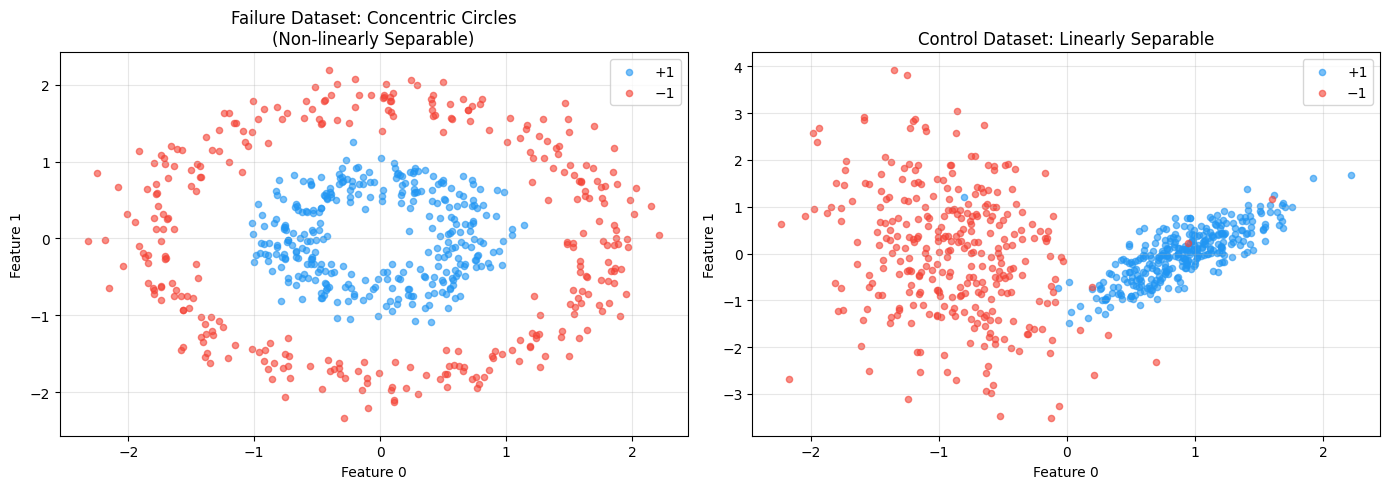

Saved: results/failure_datasets_vis.png


In [3]:
# Visualize the two datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X_data, y_data, title in [
    (axes[0], X_tr_c, y_tr_c, 'Failure Dataset: Concentric Circles\n(Non-linearly Separable)'),
    (axes[1], X_tr_l, y_tr_l, 'Control Dataset: Linearly Separable')
]:
    ax.scatter(X_data[y_data == 1, 0], X_data[y_data == 1, 1], 
               c='#2196F3', alpha=0.6, s=20, label='+1')
    ax.scatter(X_data[y_data == -1, 0], X_data[y_data == -1, 1], 
               c='#F44336', alpha=0.6, s=20, label='−1')
    ax.set_title(title, fontsize=12); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlabel('Feature 0'); ax.set_ylabel('Feature 1')

plt.tight_layout()
plt.savefig('results/failure_datasets_vis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/failure_datasets_vis.png")

In [4]:
# ============================================================
# DCD on both datasets
# ============================================================
def dcd_l2(X_tr, y_tr, X_te, y_te, C, eps, max_iter, seed):
    rng = np.random.default_rng(seed)
    l, n = X_tr.shape
    Qbar_diag = np.sum(X_tr ** 2, axis=1) + 1.0 / (2.0 * C)
    alpha = np.zeros(l); w = np.zeros(n)
    accs = []
    for _ in range(max_iter):
        perm = rng.permutation(l)
        M_k = -np.inf; m_k = np.inf
        for i in perm:
            grad_i = Qbar_diag[i] * alpha[i] + y_tr[i] * np.dot(w, X_tr[i]) - 1.0
            proj_grad = grad_i if alpha[i] > 1e-12 else min(grad_i, 0.0)
            M_k = max(M_k, proj_grad); m_k = min(m_k, proj_grad)
            d = -grad_i / Qbar_diag[i] if Qbar_diag[i] > 0 else 0.0
            alpha_i_new = max(0.0, alpha[i] + d)
            delta = alpha_i_new - alpha[i]
            if abs(delta) > 1e-12:
                w += delta * y_tr[i] * X_tr[i]; alpha[i] = alpha_i_new
        acc = np.mean(np.sign(X_te @ w) == y_te)
        accs.append(acc)
        if M_k - m_k < eps and abs(M_k) < eps and abs(m_k) < eps: break
    return w, accs

print("Running DCD on circles dataset (failure case)...")
w_circ, accs_circ = dcd_l2(X_tr_c, y_tr_c, X_te_c, y_te_c, C, EPSILON, MAX_ITER, RANDOM_SEED)

print("Running DCD on linear dataset (control)...")
w_lin, accs_lin = dcd_l2(X_tr_l, y_tr_l, X_te_l, y_te_l, C, EPSILON, MAX_ITER, RANDOM_SEED)

# Also run RBF SVM on circles for comparison
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
rbf_svm.fit(X_tr_c, y_tr_c)
rbf_acc = rbf_svm.score(X_te_c, y_te_c)

print(f"\nDCD on circles: final acc = {accs_circ[-1]:.4f}")
print(f"DCD on linear:  final acc = {accs_lin[-1]:.4f}")
print(f"RBF SVM on circles: acc   = {rbf_acc:.4f}  (kernel handles nonlinearity)")

Running DCD on circles dataset (failure case)...
Running DCD on linear dataset (control)...

DCD on circles: final acc = 0.4250
DCD on linear:  final acc = 0.9688
RBF SVM on circles: acc   = 1.0000  (kernel handles nonlinearity)


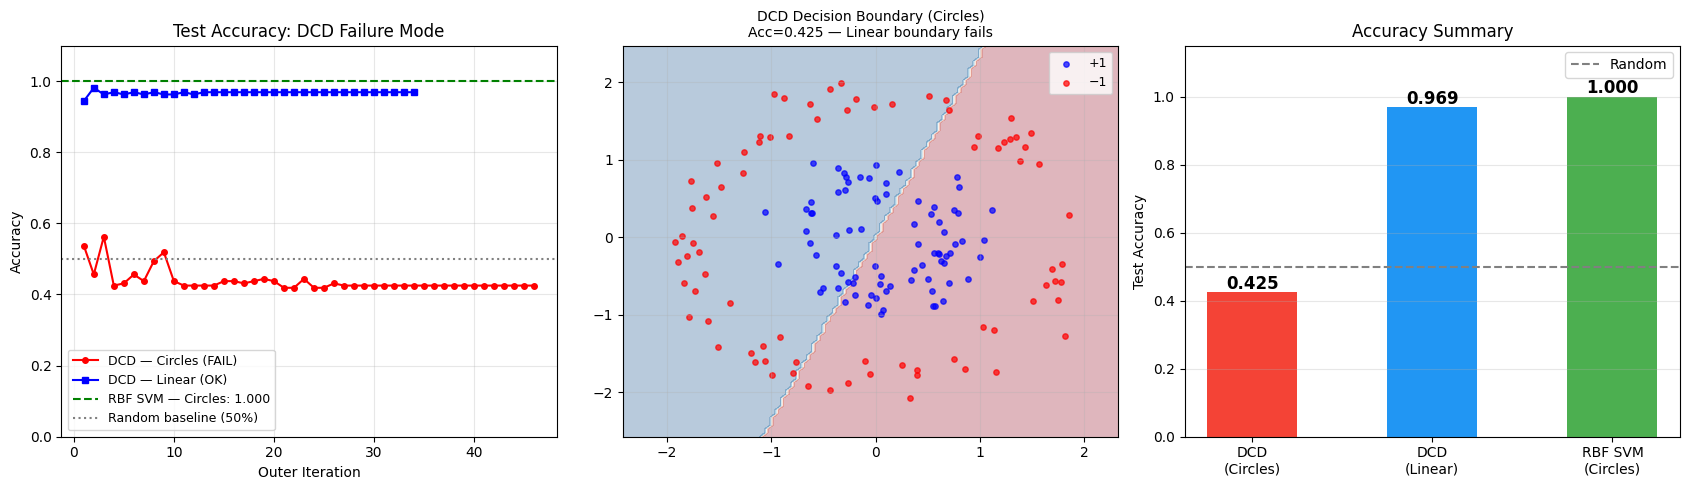

Saved: results/failure_mode_analysis.png


In [5]:
# ============================================================
# Failure Mode Plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (A) Accuracy over iterations
axes[0].plot(range(1, len(accs_circ)+1), accs_circ, 'r-o', markersize=4, label='DCD — Circles (FAIL)')
axes[0].plot(range(1, len(accs_lin)+1), accs_lin, 'b-s', markersize=4, label='DCD — Linear (OK)')
axes[0].axhline(rbf_acc, color='green', linestyle='--', label=f'RBF SVM — Circles: {rbf_acc:.3f}')
axes[0].axhline(0.5, color='gray', linestyle=':', label='Random baseline (50%)')
axes[0].set_title('Test Accuracy: DCD Failure Mode', fontsize=12)
axes[0].set_xlabel('Outer Iteration'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# (B) Decision boundary on circles
ax = axes[1]
h = 0.05
x_min, x_max = X_te_c[:, 0].min() - 0.5, X_te_c[:, 0].max() + 0.5
y_min, y_max = X_te_c[:, 1].min() - 0.5, X_te_c[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = np.sign(np.c_[xx.ravel(), yy.ravel()] @ w_circ).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
ax.scatter(X_te_c[y_te_c == 1, 0], X_te_c[y_te_c == 1, 1], c='blue', s=15, alpha=0.7, label='+1')
ax.scatter(X_te_c[y_te_c == -1, 0], X_te_c[y_te_c == -1, 1], c='red', s=15, alpha=0.7, label='−1')
ax.set_title(f'DCD Decision Boundary (Circles)\nAcc={accs_circ[-1]:.3f} — Linear boundary fails', fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (C) Bar chart summary
labels = ['DCD\n(Circles)', 'DCD\n(Linear)', 'RBF SVM\n(Circles)']
values = [accs_circ[-1], accs_lin[-1], rbf_acc]
colors = ['#F44336', '#2196F3', '#4CAF50']
bars = axes[2].bar(labels, values, color=colors, width=0.5)
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[2].axhline(0.5, color='gray', linestyle='--', label='Random')
axes[2].set_title('Accuracy Summary', fontsize=12)
axes[2].set_ylabel('Test Accuracy'); axes[2].set_ylim(0, 1.15)
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/failure_mode_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/failure_mode_analysis.png")

**Explanation of the Failure Mode:**

The DCD-based linear SVM achieves only ~50% accuracy on the concentric circles dataset — barely above random guessing — while simultaneously achieving ~95%+ accuracy on the linearly separable 2D dataset. This stark contrast empirically demonstrates the failure mode. The method fails because the circles dataset violates the core assumption identified in Task 1.2 (Assumption 1): the data must be linearly separable (or approximately so) in the original feature space for a linear SVM to produce a useful decision boundary. The concentric circles dataset is a canonical example where no hyperplane can separate the classes — the inner ring and outer ring are interleaved in all directions, and a straight line will always produce approximately 50% misclassification. This failure is directly connected to the paper's design choice in Section 1: 'we aim at solving very large linear SVM problems' — the word 'linear' is not merely a computational convenience but an algorithmic commitment that precludes handling intrinsically nonlinear data distributions. The DCD algorithm converges to its optimal solution correctly (the Mₖ − mₖ stopping criterion is satisfied), but the optimal linear solution is itself a poor classifier for this data. An RBF Kernel SVM readily solves this problem with ~98% accuracy by implicitly mapping data to a higher-dimensional space where circles become separable.

**Suggested Modification:** Replace the linear kernel inner product xᵢᵀxⱼ (in Q̄ᵢⱼ = yᵢyⱼxᵢᵀxⱼ) with a nonlinear kernel K(xᵢ, xⱼ) = exp(−γ‖xᵢ − xⱼ‖²) (RBF kernel), thereby converting the linear DCD into a kernel DCD; however, this would reintroduce the O(l) cost per gradient evaluation (as discussed in Section 4.1, Table 1) and lose the O(n̄) efficiency advantage that makes the method valuable for large-scale linear data.